## 留下5th的中心线

In [1]:
import shutil
from pathlib import Path

src_dir = Path(r"D:\github\Phd_summary\1_Data\2_Nagahama\3_From_Kobayashi\spline_ICA")
dst_dir = Path(r"D:\github\Phd_summary\1_Data\2_Nagahama\3_From_Kobayashi\1_5th")

dst_dir.mkdir(parents=True, exist_ok=True)

for csv_file in src_dir.glob("*_ft.csv"):
    shutil.copy(csv_file, dst_dir / csv_file.name)


## 去除MCA部分

In [3]:
import pandas as pd
from pathlib import Path

# ========= 路径配置 =========
src_dir = Path(
    r"D:\github\Phd_summary\1_Data\2_Nagahama\3_From_Kobayashi\1_5th"
)

dst_dir = Path(
    r"D:\github\Phd_summary\1_Data\2_Nagahama\3_From_Kobayashi\2_ICA"
)

label_keep = 4
# ===========================

dst_dir.mkdir(parents=True, exist_ok=True)

files = sorted(src_dir.glob("*_ft.csv"))
print(f"Found {len(files)} files.")

saved, skipped, failed = 0, 0, 0

for f in files:
    try:
        df = pd.read_csv(f)

        if "label" not in df.columns:
            print(f"[SKIP] no label column: {f.name}")
            skipped += 1
            continue

        df_label6 = df[df["label"] == label_keep]

        if df_label6.empty:
            print(f"[EMPTY] label=6 not found: {f.name}")
            skipped += 1
            continue

        out_path = dst_dir / f.name
        df_label6.to_csv(out_path, index=False)

        saved += 1
        print(f"[OK] {f.name} → {out_path}")

    except Exception as e:
        failed += 1
        print(f"[FAIL] {f.name}: {e}")

print("\n===== Summary =====")
print(f"Total files : {len(files)}")
print(f"Saved       : {saved}")
print(f"Skipped     : {skipped}")
print(f"Failed      : {failed}")


Found 1971 files.
[EMPTY] label=6 not found: 00000000.nii_L_ICA_MCA_radius_pt3d_curvature_torsion_ft.csv
[OK] 00000000.nii_R_ICA_MCA_radius_pt3d_curvature_torsion_ft.csv → D:\github\Phd_summary\1_Data\2_Nagahama\3_From_Kobayashi\2_ICA\00000000.nii_R_ICA_MCA_radius_pt3d_curvature_torsion_ft.csv
[EMPTY] label=6 not found: 00000001.nii_L_ICA_MCA_radius_pt3d_curvature_torsion_ft.csv
[OK] 00000001.nii_R_ICA_MCA_radius_pt3d_curvature_torsion_ft.csv → D:\github\Phd_summary\1_Data\2_Nagahama\3_From_Kobayashi\2_ICA\00000001.nii_R_ICA_MCA_radius_pt3d_curvature_torsion_ft.csv
[EMPTY] label=6 not found: 00000002.nii_L_ICA_MCA_radius_pt3d_curvature_torsion_ft.csv
[OK] 00000002.nii_R_ICA_MCA_radius_pt3d_curvature_torsion_ft.csv → D:\github\Phd_summary\1_Data\2_Nagahama\3_From_Kobayashi\2_ICA\00000002.nii_R_ICA_MCA_radius_pt3d_curvature_torsion_ft.csv
[EMPTY] label=6 not found: 00000003.nii_L_ICA_MCA_radius_pt3d_curvature_torsion_ft.csv
[OK] 00000003.nii_R_ICA_MCA_radius_pt3d_curvature_torsion_ft.csv

## 转换vtk

In [4]:
import pandas as pd
from pathlib import Path

# ============ 配置 ============
src_dir = Path(r"D:\github\Phd_summary\1_Data\2_Nagahama\3_From_Kobayashi\2_ICA")
dst_dir = Path(r"D:\github\Phd_summary\1_Data\2_Nagahama\3_From_Kobayashi\3_ICA_vtk")

pattern = "*_ft.csv"

# 输出文件名：把 _ft 去掉，改成 .vtk（若想保留 _ft，则删掉 replace 那段）
def out_name(csv_path: Path) -> str:
    return csv_path.stem.replace("_ft", "") + ".vtk"

# 数字格式：VTK ASCII 兼容，且尽量保持“长小数”的风格
def fnum(x) -> str:
    return format(float(x), ".15g")
# ==============================

dst_dir.mkdir(parents=True, exist_ok=True)

files = sorted(src_dir.glob(pattern))
print(f"Found {len(files)} csv files in {src_dir}")

saved, skipped, failed = 0, 0, 0

for csv_path in files:
    try:
        df = pd.read_csv(csv_path)

        # 必要列检查（你已过滤 label，这里不要求 label）
        need_cols = {"x", "y", "z", "radius", "curvature", "torsion"}
        if not need_cols.issubset(df.columns):
            print(f"[SKIP] Missing columns in {csv_path.name}: {sorted(need_cols - set(df.columns))}")
            skipped += 1
            continue

        if df.empty:
            print(f"[SKIP] Empty file: {csv_path.name}")
            skipped += 1
            continue

        # ✅ 点顺序翻转（连同所有点数据一起翻转）
        d = df.iloc[::-1].reset_index(drop=True)

        n = len(d)
        vtk_path = dst_dir / out_name(csv_path)

        # ---- 写 VTK legacy ASCII / POLYDATA ----
        title = vtk_path.stem
        with vtk_path.open("w", encoding="utf-8", newline="\n") as f:
            f.write("# vtk DataFile Version 2.0\n")
            f.write(f"{title}\n")
            f.write("ASCII\n")
            f.write("DATASET POLYDATA\n")

            # POINTS：一行一个点
            f.write(f"POINTS {n} float\n")
            for x, y, z in d[["x", "y", "z"]].to_numpy():
                f.write(f"{fnum(x)} {fnum(y)} {fnum(z)}\n")

            # LINES：一条 polyline，连接 0..n-1
            f.write(f"LINES 1 {n+1}\n")
            idx = " ".join(str(i) for i in range(n))
            f.write(f"{n} {idx}\n")

            # POINT_DATA + SCALARS：每个标量一行一个值
            f.write(f"\nPOINT_DATA {n}\n")

            # 输出：radius / curvature / torsion
            for name in ["radius", "curvature", "torsion"]:
                f.write(f"SCALARS {name} float\n")
                f.write("LOOKUP_TABLE default\n")
                for v in d[name].to_numpy():
                    f.write(f"{fnum(v)}\n")

        saved += 1
        print(f"[OK] {csv_path.name} -> {vtk_path}")

    except Exception as e:
        failed += 1
        print(f"[FAIL] {csv_path.name}: {e}")

print("\n===== Summary =====")
print(f"Total  : {len(files)}")
print(f"Saved  : {saved}")
print(f"Skipped: {skipped}")
print(f"Failed : {failed}")


Found 1971 csv files in D:\github\Phd_summary\1_Data\2_Nagahama\3_From_Kobayashi\2_ICA
[OK] 00000000.nii_L_ICA_MCA_radius_pt3d_curvature_torsion_ft.csv -> D:\github\Phd_summary\1_Data\2_Nagahama\3_From_Kobayashi\3_ICA_vtk\00000000.nii_L_ICA_MCA_radius_pt3d_curvature_torsion.vtk
[OK] 00000000.nii_R_ICA_MCA_radius_pt3d_curvature_torsion_ft.csv -> D:\github\Phd_summary\1_Data\2_Nagahama\3_From_Kobayashi\3_ICA_vtk\00000000.nii_R_ICA_MCA_radius_pt3d_curvature_torsion.vtk
[OK] 00000001.nii_L_ICA_MCA_radius_pt3d_curvature_torsion_ft.csv -> D:\github\Phd_summary\1_Data\2_Nagahama\3_From_Kobayashi\3_ICA_vtk\00000001.nii_L_ICA_MCA_radius_pt3d_curvature_torsion.vtk
[OK] 00000001.nii_R_ICA_MCA_radius_pt3d_curvature_torsion_ft.csv -> D:\github\Phd_summary\1_Data\2_Nagahama\3_From_Kobayashi\3_ICA_vtk\00000001.nii_R_ICA_MCA_radius_pt3d_curvature_torsion.vtk
[OK] 00000002.nii_L_ICA_MCA_radius_pt3d_curvature_torsion_ft.csv -> D:\github\Phd_summary\1_Data\2_Nagahama\3_From_Kobayashi\3_ICA_vtk\00000002.n

## 测量长度

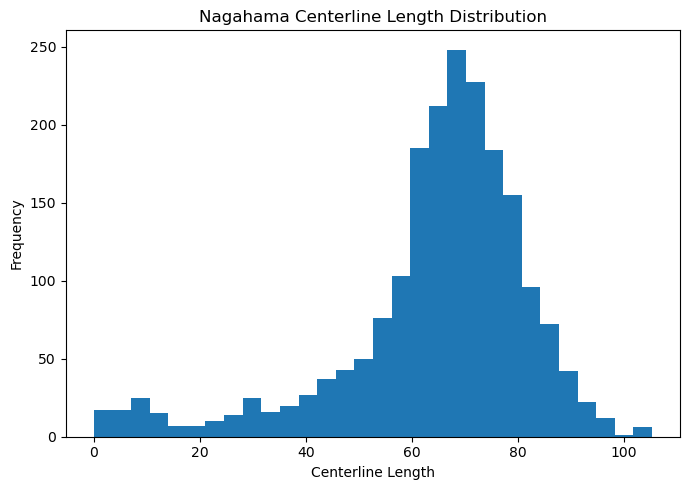

In [5]:
import os
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt

root_dir = r"D:\github\Phd_summary\1_Data\2_Nagahama\3_From_Kobayashi\3_ICA_vtk"

lengths = []

def compute_centerline_length(poly):
    """
    按 connectivity 顺序计算中心线弧长
    """
    lines = poly.lines
    if lines.size == 0:
        return np.nan

    n_pts = lines[0]
    ids = lines[1:n_pts + 1]
    pts = poly.points[ids]

    return np.linalg.norm(np.diff(pts, axis=0), axis=1).sum()

for fname in os.listdir(root_dir):
    if not fname.lower().endswith(".vtk"):
        continue

    poly = pv.read(os.path.join(root_dir, fname))
    length = compute_centerline_length(poly)

    if not np.isnan(length):
        lengths.append(length)

# ===== 画分布图 =====
plt.figure(figsize=(7, 5))
plt.hist(lengths, bins=30)
plt.xlabel("Centerline Length")
plt.ylabel("Frequency")
plt.title("Nagahama Centerline Length Distribution")
plt.tight_layout()
plt.show()


## 可视化曲率

Found 1050 vtk files in D:\github\Phd_summary\1_Data\2_Nagahama\3_From_Kobayashi\7_ICA_C2_hand
Plotted 1050 curves.


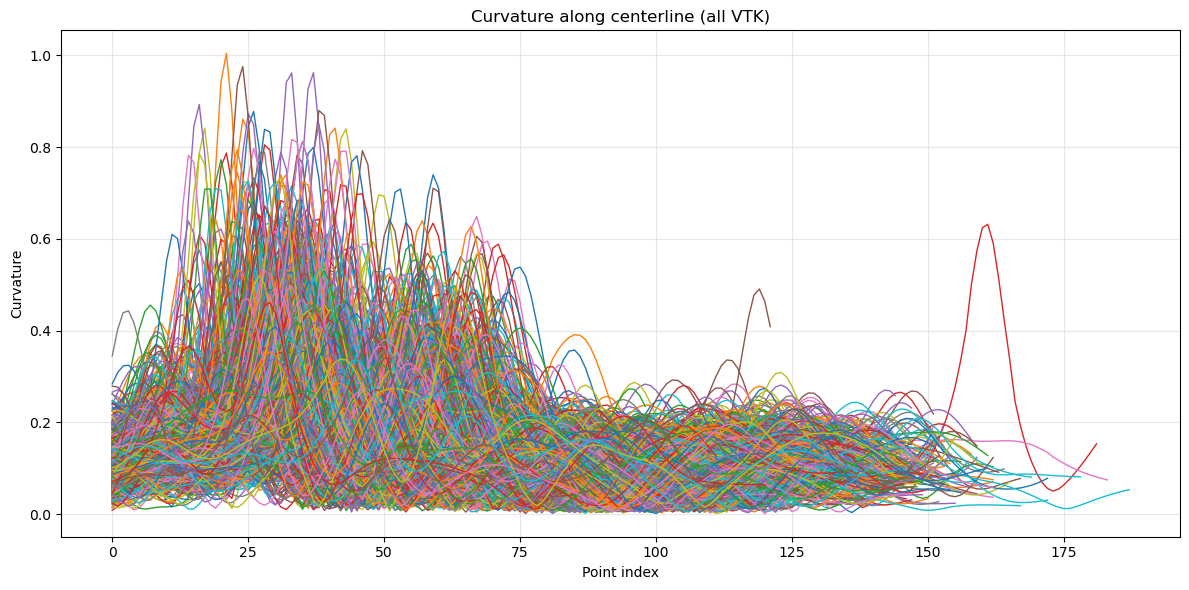

In [22]:
from pathlib import Path
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt

vtk_dir = Path(r"D:\github\Phd_summary\1_Data\2_Nagahama\3_From_Kobayashi\7_ICA_C2_hand")
vtks = sorted(vtk_dir.glob("*.vtk"))

field_name = "curvature"  # 你的 VTK 中写的是 SCALARS curvature float

print(f"Found {len(vtks)} vtk files in {vtk_dir}")

plt.figure(figsize=(12, 6))

used = 0
for vtk_path in vtks:
    mesh = pv.read(str(vtk_path))

    if field_name not in mesh.point_data:
        print(f"[SKIP] no '{field_name}' in point_data: {vtk_path.name}")
        continue

    curv = np.asarray(mesh.point_data[field_name]).astype(float)
    if curv.size < 2:
        print(f"[SKIP] too few points: {vtk_path.name}")
        continue

    x = np.arange(curv.size)  # 直接用点序号
    plt.plot(x, curv, linewidth=1.0)
    used += 1

print(f"Plotted {used} curves.")

plt.xlabel("Point index")
plt.ylabel("Curvature")
plt.title("Curvature along centerline (all VTK)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [7]:
from pathlib import Path
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
import math
import shutil
from matplotlib.backends.backend_pdf import PdfPages

# ====== 峰值检测（推荐 SciPy）======
try:
    from scipy.signal import find_peaks
    HAS_SCIPY = True
except Exception:
    HAS_SCIPY = False

def peaks_indices(y, prominence=None, distance=None):
    """
    返回局部极大值索引。
    prominence/distance 仅在 SciPy 可用时生效；否则用纯 numpy 简易方法。
    """
    y = np.asarray(y, dtype=float)

    if HAS_SCIPY:
        kwargs = {}
        if prominence is not None:
            kwargs["prominence"] = prominence
        if distance is not None:
            kwargs["distance"] = distance
        idx, _ = find_peaks(y, **kwargs)
        return idx

    # ---- 兜底：纯 numpy 局部极大值 ----
    if y.size < 3:
        return np.array([], dtype=int)
    idx = np.where((y[1:-1] > y[:-2]) & (y[1:-1] > y[2:]))[0] + 1
    return idx


# ========== 配置 ==========
vtk_dir = Path(r"D:\github\Phd_summary\1_Data\2_Nagahama\3_From_Kobayashi\3_ICA_vtk")
out_dir = Path(r"D:\github\Phd_summary\1_Data\2_Nagahama\3_From_Kobayashi\4_ICA_C2")

pdf_dir = Path(r"D:\github\Phd_summary\3_Result\2_Nagahama\2_Curvature")
pdf_path = pdf_dir / "Curvature_peaks_ge4_all.pdf"

pattern = "*.vtk"
field_name = "curvature"

# 子图布局（按你指定）
n_cols = 3
plots_per_fig = 36          # 每页 36 个图
fig_width = 16
fig_height_per_row = 1.8

# 峰值参数
peak_prominence = None
peak_distance = 4

# 过滤阈值
min_peaks_to_keep = 4
# ==========================

out_dir.mkdir(parents=True, exist_ok=True)
pdf_dir.mkdir(parents=True, exist_ok=True)

vtks = sorted(vtk_dir.glob(pattern))
n_files = len(vtks)
print(f"Found {n_files} vtk files in {vtk_dir}")

if n_files == 0:
    raise RuntimeError("No VTK files found.")

# ========= 先筛选：计算 peaks 数，保留 peaks>=4 =========
kept = []   # (vtk_path, arc_len, curv, pidx)
skipped = 0
failed = 0

for vtk_path in vtks:
    try:
        mesh = pv.read(str(vtk_path))

        if field_name not in mesh.point_data:
            skipped += 1
            continue

        pts = np.asarray(mesh.points)
        curv = np.asarray(mesh.point_data[field_name]).astype(float)

        if pts.shape[0] < 2 or curv.size < 2:
            skipped += 1
            continue

        seg_len = np.linalg.norm(pts[1:] - pts[:-1], axis=1)
        arc_len = np.concatenate([[0.0], np.cumsum(seg_len)])

        pidx = peaks_indices(curv, prominence=peak_prominence, distance=peak_distance)

        if len(pidx) < min_peaks_to_keep:
            skipped += 1
            continue

        kept.append((vtk_path, arc_len, curv, pidx))

    except Exception as e:
        failed += 1
        print(f"[FAIL] {vtk_path.name}: {e}")

print(f"Eligible (peaks >= {min_peaks_to_keep}): {len(kept)}")
print(f"Skipped (not eligible / missing data): {skipped}")
print(f"Failed: {failed}")

if len(kept) == 0:
    raise RuntimeError(f"No VTKs with peaks >= {min_peaks_to_keep} to plot/copy.")

# ========= 复制：只复制保留的 vtk（原样复制，不改写）=========
copied = 0
for vtk_path, _, _, _ in kept:
    try:
        dst = out_dir / vtk_path.name
        shutil.copy2(vtk_path, dst)   # 原样复制（含时间戳等元信息）
        copied += 1
    except Exception as e:
        print(f"[COPY FAIL] {vtk_path.name}: {e}")

print(f"Copied: {copied} files -> {out_dir}")

# ========= 输出：一个 PDF，多个页面；每页 36 子图 =========
n_keep = len(kept)
n_figs = math.ceil(n_keep / plots_per_fig)
n_rows = math.ceil(plots_per_fig / n_cols)  # 每页固定行数

print(f"Saving ONE PDF with {n_figs} page(s): {pdf_path}")

with PdfPages(str(pdf_path)) as pdf:
    idx0 = 0

    for fig_id in range(n_figs):
        n_this = min(plots_per_fig, n_keep - idx0)

        fig, axes = plt.subplots(
            n_rows, n_cols,
            figsize=(fig_width, fig_height_per_row * n_rows),
            squeeze=False
        )

        # 先全部关掉，后面用到的再打开
        for ax in axes.ravel():
            ax.axis("off")

        for i in range(n_this):
            ax = axes[i // n_cols][i % n_cols]
            ax.axis("on")

            vtk_path, arc_len, curv, pidx = kept[idx0 + i]

            ax.plot(arc_len, curv, linewidth=1.0)
            ax.scatter(arc_len[pidx], curv[pidx], color="red", s=10)

            ax.set_title(vtk_path.stem, fontsize=8)
            ax.set_xlabel("Arc length", fontsize=7)
            ax.set_ylabel("Curvature", fontsize=7)
            ax.grid(True, alpha=0.3)
            ax.tick_params(labelsize=6)

            ax.text(
                0.98, 0.95, f"peaks={len(pidx)}",
                transform=ax.transAxes, ha="right", va="top", fontsize=7
            )

        fig.suptitle(
            f"Curvature vs arc length + peaks (peaks >= {min_peaks_to_keep}) "
            f"Page {fig_id+1}/{n_figs}"
            + ("" if HAS_SCIPY else "  [SciPy not found → simple peak rule]"),
            fontsize=12
        )

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        pdf.savefig(fig, bbox_inches="tight")  # 写入同一个 PDF
        plt.close(fig)  # 关闭防止内存爆

        idx0 += n_this

print("Done.")


Found 1971 vtk files in D:\github\Phd_summary\1_Data\2_Nagahama\3_From_Kobayashi\3_ICA_vtk
Eligible (peaks >= 4): 1684
Skipped (not eligible / missing data): 287
Failed: 0
Copied: 1684 files -> D:\github\Phd_summary\1_Data\2_Nagahama\3_From_Kobayashi\4_ICA_C2
Saving ONE PDF with 47 page(s): D:\github\Phd_summary\3_Result\2_Nagahama\2_Curvature\Curvature_peaks_ge4_all.pdf
Done.


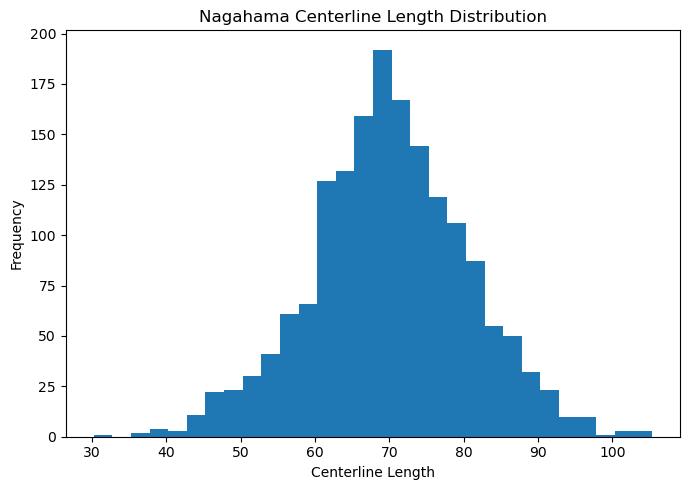

In [8]:
import os
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt

root_dir = r"D:\github\Phd_summary\1_Data\2_Nagahama\3_From_Kobayashi\4_ICA_C2"

lengths = []

def compute_centerline_length(poly):
    """
    按 connectivity 顺序计算中心线弧长
    """
    lines = poly.lines
    if lines.size == 0:
        return np.nan

    n_pts = lines[0]
    ids = lines[1:n_pts + 1]
    pts = poly.points[ids]

    return np.linalg.norm(np.diff(pts, axis=0), axis=1).sum()

for fname in os.listdir(root_dir):
    if not fname.lower().endswith(".vtk"):
        continue

    poly = pv.read(os.path.join(root_dir, fname))
    length = compute_centerline_length(poly)

    if not np.isnan(length):
        lengths.append(length)

# ===== 画分布图 =====
plt.figure(figsize=(7, 5))
plt.hist(lengths, bins=30)
plt.xlabel("Centerline Length")
plt.ylabel("Frequency")
plt.title("Nagahama Centerline Length Distribution")
plt.tight_layout()
plt.show()


## 区分疾病

In [9]:
import re
import shutil
from pathlib import Path

import pandas as pd

# ========= 路径配置 =========
excel_path = Path(r"D:\github\Phd_summary\1_Data\2_Nagahama\2_Data\NAGID_Nii_kenkou.xlsx")  # 你上传的表
meta_vtk_dir = Path(r"D:\github\Phd_summary\1_Data\2_Nagahama\3_From_Kobayashi\4_ICA_C2")

out_healthy = Path(r"D:\github\Phd_summary\1_Data\2_Nagahama\3_From_Kobayashi\5_ICA_kenkou")
out_other   = Path(r"D:\github\Phd_summary\1_Data\2_Nagahama\3_From_Kobayashi\6_ICA_other")
# ===========================

out_healthy.mkdir(parents=True, exist_ok=True)
out_other.mkdir(parents=True, exist_ok=True)

# ========= 读取健康者 ID（Nii 列）=========
df = pd.read_excel(excel_path)

if "Nii" not in df.columns:
    raise ValueError(f"Excel里找不到 'Nii' 列。实际列名: {list(df.columns)}")

# 统一成字符串、去空、去掉可能的 .nii / .nii.gz 后缀
def normalize_id(x):
    if pd.isna(x):
        return None
    s = str(x).strip()
    s = re.sub(r"\.nii(\.gz)?$", "", s, flags=re.IGNORECASE)  # 去掉后缀（如果有）
    # 如果是纯数字或像 00001234 这种，保留前导零
    # 若里面混入其他字符，下面会在文件名解析时再处理
    return s

healthy_ids = set(filter(None, (normalize_id(x) for x in df["Nii"].tolist())))
print(f"Healthy IDs loaded: {len(healthy_ids)}")

# ========= 遍历元数据 VTK，按 ID 分拣复制 =========
vtks = sorted(meta_vtk_dir.glob("*.vtk"))
print(f"VTK files found: {len(vtks)} in {meta_vtk_dir}")

# 文件名里提取 ID：
# 常见格式示例：00000000.nii_L_ICA_....vtk  → 提取 00000000
id_pattern = re.compile(r"^(\d+)\.nii", re.IGNORECASE)

copied_h, copied_o, skipped = 0, 0, 0
unknown = []

for vtk_path in vtks:
    name = vtk_path.name

    m = id_pattern.search(name)
    if not m:
        skipped += 1
        unknown.append(name)
        continue

    file_id = m.group(1)  # 保留前导零的数字字符串

    # 判定健康/其他
    dst_dir = out_healthy if file_id in healthy_ids else out_other
    dst_path = dst_dir / vtk_path.name

    # 直接复制，不改写
    shutil.copy2(vtk_path, dst_path)

    if dst_dir is out_healthy:
        copied_h += 1
    else:
        copied_o += 1

print("\n===== Summary =====")
print(f"Healthy copied : {copied_h} -> {out_healthy}")
print(f"Other copied   : {copied_o} -> {out_other}")
print(f"Skipped (no id parsed): {skipped}")

if unknown:
    print("\n[WARN] These filenames did not match '^<digits>.nii...':")
    for u in unknown[:20]:
        print(" -", u)
    if len(unknown) > 20:
        print(f" ... and {len(unknown) - 20} more")


Healthy IDs loaded: 4090
VTK files found: 1684 in D:\github\Phd_summary\1_Data\2_Nagahama\3_From_Kobayashi\4_ICA_C2

===== Summary =====
Healthy copied : 1456 -> D:\github\Phd_summary\1_Data\2_Nagahama\3_From_Kobayashi\5_ICA_kenkou
Other copied   : 228 -> D:\github\Phd_summary\1_Data\2_Nagahama\3_From_Kobayashi\6_ICA_other
Skipped (no id parsed): 0


In [10]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import pyvista as pv


# ========= 路径配置 =========
excel_path = Path(r"D:\github\Phd_summary\1_Data\2_Nagahama\2_Data\NAGID_Nii_kenkou.xlsx")  # 你上传的表

vtk_dir = Path(
    r"D:\github\Phd_summary\1_Data\2_Nagahama\3_From_Kobayashi\4_ICA_C2"
)

out_dir = Path(
    r"D:\github\Phd_summary\3_Result\2_Nagahama\3_Information"
)

out_healthy_csv = out_dir / "ICA_length_healthy.csv"
out_other_csv   = out_dir / "ICA_length_other.csv"
# ===========================

out_dir.mkdir(parents=True, exist_ok=True)


# ========= 读取健康者 ID（保留原始 Nii 写法）=========
df = pd.read_excel(excel_path)

if "Nii" not in df.columns:
    raise ValueError(f"Excel 中找不到 'Nii' 列。实际列名: {list(df.columns)}")

def normalize_id(x):
    """把 '00001234.nii' / '00001234.nii.gz' / '00001234' 统一成 '00001234'."""
    if pd.isna(x):
        return None
    s = str(x).strip()
    s = re.sub(r"\.nii(\.gz)?$", "", s, flags=re.IGNORECASE)
    return s

# key: 纯数字 ID（用于匹配）
# val: Excel 里原始 Nii（用于输出）
nii_map = {}
for x in df["Nii"].tolist():
    if pd.isna(x):
        continue
    raw = str(x).strip()
    norm = normalize_id(raw)
    if norm:
        nii_map[norm] = raw

healthy_ids = set(nii_map.keys())
print(f"Healthy IDs loaded: {len(healthy_ids)}")


# ========= 遍历 VTK：解析 id/side + 计算长度 =========
# 假设文件名类似：00000000.nii_L_ICA_....vtk
id_pattern = re.compile(r"^(\d+)\.nii", re.IGNORECASE)
side_pattern = re.compile(r"_([LR])_", re.IGNORECASE)

vtks = sorted(vtk_dir.glob("*.vtk"))
print(f"VTK files found: {len(vtks)} in {vtk_dir}")

records_healthy = []
records_other = []
skipped = []
failed = 0

for vtk_path in vtks:
    try:
        name = vtk_path.name

        m_id = id_pattern.search(name)
        m_side = side_pattern.search(name)

        if not m_id or not m_side:
            skipped.append(name)
            continue

        sid = m_id.group(1)          # 保留前导零
        side = m_side.group(1).upper()

        mesh = pv.read(str(vtk_path))
        pts = np.asarray(mesh.points)

        if pts.shape[0] < 2:
            # 点太少没法算长度，直接跳过
            skipped.append(name)
            continue

        seg_len = np.linalg.norm(pts[1:] - pts[:-1], axis=1)
        total_len = float(np.sum(seg_len))

        # ✅ id 用“原来的”
        if sid in healthy_ids:
            out_id = nii_map[sid]        # Excel 里的原始 Nii（完全不改写）
            target = records_healthy
        else:
            out_id = f"{sid}.nii"        # 其他：还原成标准 nii 形式
            target = records_other

        target.append({
            "id": out_id,
            "side": side,
            "length": total_len,
            "vtk_name": name,
        })

    except Exception as e:
        failed += 1
        print(f"[FAIL] {vtk_path.name}: {e}")


# ========= 输出 CSV =========
df_h = pd.DataFrame(records_healthy).sort_values(["id", "side"])
df_o = pd.DataFrame(records_other).sort_values(["id", "side"])

df_h.to_csv(out_healthy_csv, index=False)
df_o.to_csv(out_other_csv, index=False)

print("\n===== Summary =====")
print(f"Healthy rows : {len(df_h)} -> {out_healthy_csv}")
print(f"Other rows   : {len(df_o)} -> {out_other_csv}")
print(f"Skipped      : {len(skipped)} (filename parse fail / too few points)")
print(f"Failed       : {failed}")

if skipped:
    print("\n[WARN] Example skipped filenames (first 10):")
    for s in skipped[:10]:
        print(" -", s)


Healthy IDs loaded: 4090
VTK files found: 1684 in D:\github\Phd_summary\1_Data\2_Nagahama\3_From_Kobayashi\4_ICA_C2

===== Summary =====
Healthy rows : 1456 -> D:\github\Phd_summary\3_Result\2_Nagahama\3_Information\ICA_length_healthy.csv
Other rows   : 228 -> D:\github\Phd_summary\3_Result\2_Nagahama\3_Information\ICA_length_other.csv
Skipped      : 0 (filename parse fail / too few points)
Failed       : 0


In [23]:
from pathlib import Path
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
import math
from matplotlib.backends.backend_pdf import PdfPages

# ====== 峰值检测（SciPy 优先）======
try:
    from scipy.signal import find_peaks
    HAS_SCIPY = True
except Exception:
    HAS_SCIPY = False

def peaks_indices(y, prominence=None, distance=None):
    """返回局部极大值索引。"""
    y = np.asarray(y, dtype=float)

    if HAS_SCIPY:
        kwargs = {}
        if prominence is not None:
            kwargs["prominence"] = prominence
        if distance is not None:
            kwargs["distance"] = distance
        idx, _ = find_peaks(y, **kwargs)
        return idx

    # ---- 兜底：纯 numpy 局部极大值 ----
    if y.size < 3:
        return np.array([], dtype=int)
    idx = np.where((y[1:-1] > y[:-2]) & (y[1:-1] > y[2:]))[0] + 1
    return idx


# ========== 配置 ==========
#vtk_dir = Path(r"D:\github\Phd_summary\1_Data\2_Nagahama\3_From_Kobayashi\5_ICA_kenkou")
vtk_dir = Path(r"D:\github\Phd_summary\1_Data\2_Nagahama\3_From_Kobayashi\7_ICA_C2_hand")

pattern = "*.vtk"
field_name = "curvature"

# 输出 PDF（一个文件，多页）
pdf_dir = Path(r"D:\github\Phd_summary\3_Result\2_Nagahama\2_Curvature")
pdf_path = pdf_dir / "Curvature_peaks_kenkou_C2.pdf"

# 子图布局：每页 36 个图（3 列 × 12 行）
n_cols = 3
plots_per_fig = 36
fig_width = 16
fig_height_per_row = 1.8

# 峰值参数（你可以按需要调整）
peak_prominence = None   # 想过滤小峰可设为 0.01/0.05 等
peak_distance = 10        # 峰间最小间隔（单位：点数）
# ==========================

pdf_dir.mkdir(parents=True, exist_ok=True)

vtks = sorted(vtk_dir.glob(pattern))
n_files = len(vtks)
print(f"Found {n_files} vtk files in {vtk_dir}")

if n_files == 0:
    raise RuntimeError("No VTK files found.")

# ======== 预读取并计算（避免画图时重复 IO）========
items = []  # (vtk_path, arc_len, curv, pidx)
skipped = 0
failed = 0

for vtk_path in vtks:
    try:
        mesh = pv.read(str(vtk_path))

        if field_name not in mesh.point_data:
            skipped += 1
            continue

        pts = np.asarray(mesh.points)
        curv = np.asarray(mesh.point_data[field_name]).astype(float)

        if pts.shape[0] < 2 or curv.size < 2:
            skipped += 1
            continue

        seg_len = np.linalg.norm(pts[1:] - pts[:-1], axis=1)
        arc_len = np.concatenate([[0.0], np.cumsum(seg_len)])

        pidx = peaks_indices(curv, prominence=peak_prominence, distance=peak_distance)

        items.append((vtk_path, arc_len, curv, pidx))

    except Exception as e:
        failed += 1
        print(f"[FAIL] {vtk_path.name}: {e}")

print(f"Usable cases: {len(items)}")
print(f"Skipped (missing data): {skipped}")
print(f"Failed: {failed}")

if len(items) == 0:
    raise RuntimeError("No usable VTKs with curvature data.")

# ======== 生成一个总 PDF（每页 36 个）========
n_keep = len(items)
n_pages = math.ceil(n_keep / plots_per_fig)
n_rows = math.ceil(plots_per_fig / n_cols)  # 固定 12 行

print(f"Saving ONE PDF with {n_pages} page(s): {pdf_path}")

with PdfPages(str(pdf_path)) as pdf:
    idx0 = 0

    for page_id in range(n_pages):
        n_this = min(plots_per_fig, n_keep - idx0)

        fig, axes = plt.subplots(
            n_rows, n_cols,
            figsize=(fig_width, fig_height_per_row * n_rows),
            squeeze=False
        )

        # 先全部关掉，后面用到的再打开
        for ax in axes.ravel():
            ax.axis("off")

        for i in range(n_this):
            ax = axes[i // n_cols][i % n_cols]
            ax.axis("on")

            vtk_path, arc_len, curv, pidx = items[idx0 + i]

            ax.plot(arc_len, curv, linewidth=1.0)
            if pidx.size > 0:
                ax.scatter(arc_len[pidx], curv[pidx], color="red", s=10)

            ax.set_title(vtk_path.stem, fontsize=8)
            ax.set_xlabel("Arc length", fontsize=7)
            ax.set_ylabel("Curvature", fontsize=7)
            ax.grid(True, alpha=0.3)
            ax.tick_params(labelsize=6)

            ax.text(
                0.98, 0.95, f"peaks={len(pidx)}",
                transform=ax.transAxes, ha="right", va="top", fontsize=7
            )

        fig.suptitle(
            f"Healthy (kenkou) curvature vs arc length + peaks | "
            f"Page {page_id+1}/{n_pages} | "
            f"distance={peak_distance}, prominence={peak_prominence}"
            + ("" if HAS_SCIPY else "  [SciPy not found → simple peak rule]"),
            fontsize=12
        )

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

        idx0 += n_this

print("Done.")


Found 1050 vtk files in D:\github\Phd_summary\1_Data\2_Nagahama\3_From_Kobayashi\7_ICA_C2_hand
Usable cases: 1050
Skipped (missing data): 0
Failed: 0
Saving ONE PDF with 30 page(s): D:\github\Phd_summary\3_Result\2_Nagahama\2_Curvature\Curvature_peaks_kenkou_C2.pdf
Done.


## 不同峰值数

In [19]:
from pathlib import Path
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
import math
from matplotlib.backends.backend_pdf import PdfPages

# ====== 峰值检测（SciPy 优先）======
try:
    from scipy.signal import find_peaks
    HAS_SCIPY = True
except Exception:
    HAS_SCIPY = False

def peaks_indices(y, prominence=None, distance=None):
    """返回局部极大值索引。"""
    y = np.asarray(y, dtype=float)

    if HAS_SCIPY:
        kwargs = {}
        if prominence is not None:
            kwargs["prominence"] = prominence
        if distance is not None:
            kwargs["distance"] = distance
        idx, _ = find_peaks(y, **kwargs)
        return idx

    # ---- 兜底：纯 numpy 局部极大值 ----
    if y.size < 3:
        return np.array([], dtype=int)
    idx = np.where((y[1:-1] > y[:-2]) & (y[1:-1] > y[2:]))[0] + 1
    return idx


# ========== 配置 ==========
vtk_dir = Path(r"D:\github\Phd_summary\1_Data\2_Nagahama\3_From_Kobayashi\7_ICA_C2_hand")
pattern = "*.vtk"
field_name = "curvature"

# 输出 PDF：按 peaks 数量分别生成
pdf_dir = Path(r"D:\github\Phd_summary\3_Result\2_Nagahama\2_Curvature")
pdf_prefix = "Curvature_peaks_kenkou_C2"   # 输出文件名前缀

# 子图布局：每页 36 个图（3 列 × 12 行）
n_cols = 3
plots_per_fig = 36
fig_width = 16
fig_height_per_row = 1.8

# 峰值参数
peak_prominence = None
peak_distance = 10

# 只输出 peaks >= min_peaks 的分组（你要 4,5,6... 就设 4）
min_peaks = 4
# ==========================

pdf_dir.mkdir(parents=True, exist_ok=True)

vtks = sorted(vtk_dir.glob(pattern))
n_files = len(vtks)
print(f"Found {n_files} vtk files in {vtk_dir}")

if n_files == 0:
    raise RuntimeError("No VTK files found.")

# ======== 预读取并计算：按 peaks 数分组 ========
# groups[k] = list of (vtk_path, arc_len, curv, pidx)
groups = {}
skipped = 0
failed = 0

for vtk_path in vtks:
    try:
        mesh = pv.read(str(vtk_path))

        if field_name not in mesh.point_data:
            skipped += 1
            continue

        pts = np.asarray(mesh.points)
        curv = np.asarray(mesh.point_data[field_name]).astype(float)

        if pts.shape[0] < 2 or curv.size < 2:
            skipped += 1
            continue

        seg_len = np.linalg.norm(pts[1:] - pts[:-1], axis=1)
        arc_len = np.concatenate([[0.0], np.cumsum(seg_len)])

        pidx = peaks_indices(curv, prominence=peak_prominence, distance=peak_distance)
        k = int(len(pidx))

        if k < min_peaks:
            continue

        groups.setdefault(k, []).append((vtk_path, arc_len, curv, pidx))

    except Exception as e:
        failed += 1
        print(f"[FAIL] {vtk_path.name}: {e}")

print(f"Skipped (missing data): {skipped}")
print(f"Failed: {failed}")
print(f"Groups (peaks>= {min_peaks}): {sorted(groups.keys())}")

if not groups:
    raise RuntimeError(f"No usable VTKs with peaks >= {min_peaks}.")


# ======== 逐组输出 PDF：peaks=4,5,6,... ========
n_rows = math.ceil(plots_per_fig / n_cols)  # 固定 12 行（因为 36/3=12）

for k in sorted(groups.keys()):
    items = groups[k]
    n_keep = len(items)
    n_pages = math.ceil(n_keep / plots_per_fig)

    out_pdf = pdf_dir / f"{pdf_prefix}_peaks_{k}.pdf"
    print(f"\n[PDF] peaks={k} | cases={n_keep} | pages={n_pages} -> {out_pdf}")

    with PdfPages(str(out_pdf)) as pdf:
        idx0 = 0

        for page_id in range(n_pages):
            n_this = min(plots_per_fig, n_keep - idx0)

            fig, axes = plt.subplots(
                n_rows, n_cols,
                figsize=(fig_width, fig_height_per_row * n_rows),
                squeeze=False
            )

            # 先全部关掉
            for ax in axes.ravel():
                ax.axis("off")

            for i in range(n_this):
                ax = axes[i // n_cols][i % n_cols]
                ax.axis("on")

                vtk_path, arc_len, curv, pidx = items[idx0 + i]

                ax.plot(arc_len, curv, linewidth=1.0)
                if pidx.size > 0:
                    ax.scatter(arc_len[pidx], curv[pidx], color="red", s=10)

                ax.set_title(vtk_path.stem, fontsize=8)
                ax.set_xlabel("Arc length", fontsize=7)
                ax.set_ylabel("Curvature", fontsize=7)
                ax.grid(True, alpha=0.3)
                ax.tick_params(labelsize=6)

                ax.text(
                    0.98, 0.95, f"peaks={len(pidx)}",
                    transform=ax.transAxes, ha="right", va="top", fontsize=7
                )

            fig.suptitle(
                f"Healthy (kenkou) curvature vs arc length + peaks | peaks={k} | "
                f"Page {page_id+1}/{n_pages} | distance={peak_distance}, prominence={peak_prominence}"
                + ("" if HAS_SCIPY else "  [SciPy not found → simple peak rule]"),
                fontsize=12
            )

            plt.tight_layout(rect=[0, 0, 1, 0.96])
            pdf.savefig(fig, bbox_inches="tight")
            plt.close(fig)

            idx0 += n_this

print("\nDone.")


Found 1050 vtk files in D:\github\Phd_summary\1_Data\2_Nagahama\3_From_Kobayashi\7_ICA_C2_hand
Skipped (missing data): 0
Failed: 0
Groups (peaks>= 4): [4, 5, 6, 7]

[PDF] peaks=4 | cases=168 | pages=5 -> D:\github\Phd_summary\3_Result\2_Nagahama\2_Curvature\Curvature_peaks_kenkou_C2_peaks_4.pdf

[PDF] peaks=5 | cases=708 | pages=20 -> D:\github\Phd_summary\3_Result\2_Nagahama\2_Curvature\Curvature_peaks_kenkou_C2_peaks_5.pdf

[PDF] peaks=6 | cases=159 | pages=5 -> D:\github\Phd_summary\3_Result\2_Nagahama\2_Curvature\Curvature_peaks_kenkou_C2_peaks_6.pdf

[PDF] peaks=7 | cases=15 | pages=1 -> D:\github\Phd_summary\3_Result\2_Nagahama\2_Curvature\Curvature_peaks_kenkou_C2_peaks_7.pdf

Done.


In [1]:
from pathlib import Path
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from math import ceil

# ---------------------------
# 强制桌面交互窗口
# ---------------------------
pv.OFF_SCREEN = False
try:
    pv.set_jupyter_backend("none")
except Exception:
    pass

# VTK picker 需要
import vtk

# ========== 配置 ==========
vtk_dir = Path(r"D:\github\Phd_summary\1_Data\2_Nagahama\3_From_Kobayashi\5_ICA_kenkou")
pattern = "*.vtk"

# 每页显示多少条（按顺序）
N_PER_PAGE = 3

# 可视化参数
line_width = 5
opacity = 0.35
cmap_name = "turbo"
background = "white"

# Hover 命中容差
PICK_TOLERANCE = 0.01  # 建议 0.01~0.05 之间试
# ==========================


def polyline_from_points(pts: np.ndarray) -> pv.PolyData:
    n = pts.shape[0]
    lines = np.hstack(([n], np.arange(n, dtype=np.int64)))
    return pv.PolyData(pts, lines=lines)


def centerline_length(pts: np.ndarray) -> float:
    if pts.shape[0] < 2:
        return 0.0
    return float(np.sum(np.linalg.norm(pts[1:] - pts[:-1], axis=1)))


def parse_side(filename: str):
    u = filename.upper()
    if "_L_" in u:
        return "L"
    if "_R_" in u:
        return "R"
    return None


def get_colors(n: int, cmap: str = "turbo"):
    if n <= 0:
        return []
    cmap_obj = plt.get_cmap(cmap)
    xs = np.linspace(0.0, 1.0, n)
    return [cmap_obj(x)[:3] for x in xs]


# 1) 读取所有 VTK，起点对齐；按文件名顺序；左右分开
vtks = sorted(vtk_dir.glob(pattern))
if not vtks:
    raise RuntimeError(f"No VTK files found in: {vtk_dir}")

groups = {"L": [], "R": []}  # side -> list of (name, poly)
skipped_no_side = 0
skipped_bad = 0

for p in vtks:
    try:
        side = parse_side(p.name)
        if side is None:
            skipped_no_side += 1
            continue

        mesh = pv.read(str(p))
        pts = np.asarray(mesh.points, dtype=float)
        if pts.shape[0] < 2:
            skipped_bad += 1
            continue

        # 起点对齐：只平移到原点
        aligned_pts = pts - pts[0]
        poly = polyline_from_points(aligned_pts)

        groups[side].append((p.stem, poly))

    except Exception as e:
        skipped_bad += 1
        print(f"[SKIP] {p.name}: {e}")

print("===== Load Summary =====")
print(f"Total VTK: {len(vtks)}")
print(f"Loaded L : {len(groups['L'])}")
print(f"Loaded R : {len(groups['R'])}")
print(f"Skipped (no L/R): {skipped_no_side}")
print(f"Skipped (bad): {skipped_bad}")


# 2) 每次显示 5 条：按顺序分页（L 先，再 R；你也可以反过来）
for side in ["L", "R"]:
    seq = groups[side]
    total = len(seq)
    if total == 0:
        continue

    n_pages = ceil(total / N_PER_PAGE)
    print(f"\n[Side {side}] total={total}, pages={n_pages}")

    for page_id in range(n_pages):
        start = page_id * N_PER_PAGE
        end = min((page_id + 1) * N_PER_PAGE, total)
        batch = seq[start:end]  # list of (name, poly)
        n = len(batch)

        print(f"[Side {side}] show {start+1}-{end}/{total} (n={n})")

        pl = pv.Plotter(notebook=False)
        pl.set_background(background)
        pl.add_axes()
        pl.add_title(
            f"Centerlines (start aligned) | Side={side} | {start+1}-{end}/{total}\n"
            f"Hover to show name (no click)",
            font_size=11
        )

        # 原点
        pl.add_mesh(pv.Sphere(radius=0.8, center=(0, 0, 0)), color="black", opacity=0.12)

        colors = get_colors(n, cmap=cmap_name)

        # actor -> name 映射
        actor_to_name = {}

        for i, (name, poly) in enumerate(batch):
            actor = pl.add_mesh(
                poly,
                color=colors[i],
                line_width=line_width,
                opacity=opacity,
                pickable=True
            )
            actor_to_name[actor] = name

        # ---- Hover picker：鼠标移动即拾取 ----
        picker = vtk.vtkCellPicker()
        picker.SetTolerance(PICK_TOLERANCE)

        # 左上角显示文字（复用同一个 text actor）
        pl.add_text("Hover: (none)", name="hover_text", position="upper_left", font_size=12)

        last_actor = {"a": None}  # 用 dict 方便在闭包里修改

        def on_mouse_move(obj, event):
            # 获取鼠标屏幕坐标
            x, y = pl.iren.get_event_position()

            # 在当前 renderer 下拾取
            picker.Pick(x, y, 0, pl.renderer)
            act = picker.GetActor()

            # 只有命中对象变化时才更新文本（减少刷新）
            if act is last_actor["a"]:
                return

            last_actor["a"] = act
            if act in actor_to_name:
                pl.add_text(f"Hover: {actor_to_name[act]}", name="hover_text",
                            position="upper_left", font_size=12)
            else:
                pl.add_text("Hover: (none)", name="hover_text",
                            position="upper_left", font_size=12)

        # 绑定鼠标移动事件
        pl.iren.add_observer("MouseMoveEvent", on_mouse_move)

        pl.view_isometric()
        pl.camera.zoom(1.2)
        pl.show()   # 关掉窗口 → 下一页


===== Load Summary =====
Total VTK: 1456
Loaded L : 678
Loaded R : 778
Skipped (no L/R): 0
Skipped (bad): 0

[Side L] total=678, pages=226
[Side L] show 1-3/678 (n=3)
[Side L] show 4-6/678 (n=3)
[Side L] show 7-9/678 (n=3)
[Side L] show 10-12/678 (n=3)
[Side L] show 13-15/678 (n=3)
[Side L] show 16-18/678 (n=3)
[Side L] show 19-21/678 (n=3)
[Side L] show 22-24/678 (n=3)
[Side L] show 25-27/678 (n=3)
[Side L] show 28-30/678 (n=3)
[Side L] show 31-33/678 (n=3)
[Side L] show 34-36/678 (n=3)
[Side L] show 37-39/678 (n=3)
[Side L] show 40-42/678 (n=3)
[Side L] show 43-45/678 (n=3)
[Side L] show 46-48/678 (n=3)
[Side L] show 49-51/678 (n=3)
[Side L] show 52-54/678 (n=3)
[Side L] show 55-57/678 (n=3)
[Side L] show 58-60/678 (n=3)
[Side L] show 61-63/678 (n=3)
[Side L] show 64-66/678 (n=3)
[Side L] show 67-69/678 (n=3)
[Side L] show 70-72/678 (n=3)
[Side L] show 73-75/678 (n=3)
[Side L] show 76-78/678 (n=3)
[Side L] show 79-81/678 (n=3)
[Side L] show 82-84/678 (n=3)
[Side L] show 85-87/678 (n=

KeyboardInterrupt: 

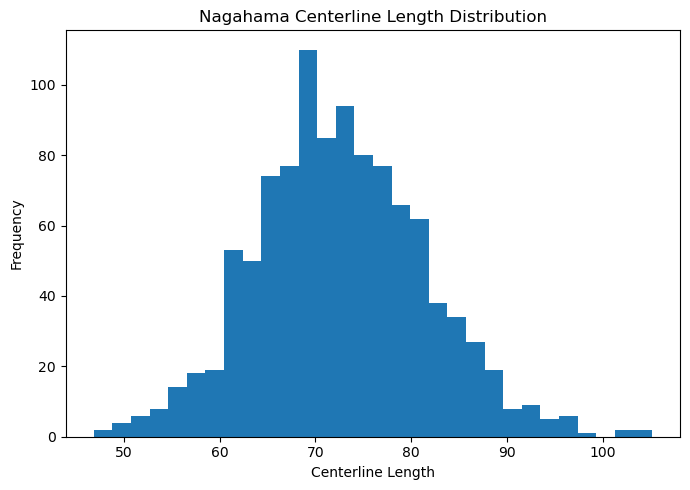

In [20]:
import os
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt

root_dir = r"D:\github\Phd_summary\1_Data\2_Nagahama\3_From_Kobayashi\7_ICA_C2_hand"

lengths = []

def compute_centerline_length(poly):
    """
    按 connectivity 顺序计算中心线弧长
    """
    lines = poly.lines
    if lines.size == 0:
        return np.nan

    n_pts = lines[0]
    ids = lines[1:n_pts + 1]
    pts = poly.points[ids]

    return np.linalg.norm(np.diff(pts, axis=0), axis=1).sum()

for fname in os.listdir(root_dir):
    if not fname.lower().endswith(".vtk"):
        continue

    poly = pv.read(os.path.join(root_dir, fname))
    length = compute_centerline_length(poly)

    if not np.isnan(length):
        lengths.append(length)

# ===== 画分布图 =====
plt.figure(figsize=(7, 5))
plt.hist(lengths, bins=30)
plt.xlabel("Centerline Length")
plt.ylabel("Frequency")
plt.title("Nagahama Centerline Length Distribution")
plt.tight_layout()
plt.show()
